# 1.  Problem Definition
Build a model that predicts excess returns and includes a betting strategy designed to outperform the S&P 500 while staying within a 120% volatility constraint.

# 2. Data
It was provided at the competition link itself. It's structured data (.csv files)

In [2]:
import zipfile
import os

zip_path= "hull-tactical-market-prediction.zip"
extract_path= "hull-tactical-unzip-dataset"

# Create dir
os.makedirs(extract_path, exist_ok= True)

# Extract
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Complete!")

Extraction Complete!


In [3]:
import os

for file in os.listdir(extract_path):
    print(file)

kaggle_evaluation
test.csv
train.csv


# 3. Evaluation
To predict an “investment position” (between 0 and 2) that **maximizes** a special metric — **"a volatility-adjusted Sharpe ratio."**

The model’s predictions determine how much of the market you “invest” in at each time step (row).

Then the evaluation script:
1. Simulates the strategy’s returns using our predicted positions.
2. Compares our volatility vs. the market.
3. Applies penalties if model is too risky or underperforms the market.

# 4. Features
We have 98 columns/features in this particular dataset corresponding various metrices of finance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
train_df= pd.read_csv("hull-tactical-unzip-dataset/train.csv")

In [3]:
train_df

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8985,8985,0,0,0,0,0,0,0,0,0,...,0.469577,0.837963,1.226772,0.822751,-0.707361,0.142857,-0.649616,0.002457,0.000155,0.001990
8986,8986,0,0,0,0,0,0,0,0,0,...,0.671958,0.837963,0.785877,0.805556,-0.715692,0.196098,-0.668289,0.002312,0.000156,0.001845
8987,8987,0,0,1,0,0,0,0,0,0,...,0.481481,0.787698,0.834898,0.823413,-0.723949,0.133929,-0.670946,0.002891,0.000156,0.002424
8988,8988,0,0,0,0,0,0,0,0,0,...,0.655423,0.783730,0.994026,0.851852,-0.684937,0.101852,-0.646265,0.008310,0.000156,0.007843


In [4]:
train_df.columns

Index(['date_id', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1',
       'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19',
       'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'I1', 'I2', 'I3',
       'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'M1', 'M10', 'M11', 'M12', 'M13',
       'M14', 'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7',
       'M8', 'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5',
       'P6', 'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S3', 'S4',
       'S5', 'S6', 'S7', 'S8', 'S9', 'V1', 'V10', 'V11', 'V12', 'V13', 'V2',
       'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'forward_returns',
       'risk_free_rate', 'market_forward_excess_returns'],
      dtype='object')

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8990 entries, 0 to 8989
Data columns (total 98 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date_id                        8990 non-null   int64  
 1   D1                             8990 non-null   int64  
 2   D2                             8990 non-null   int64  
 3   D3                             8990 non-null   int64  
 4   D4                             8990 non-null   int64  
 5   D5                             8990 non-null   int64  
 6   D6                             8990 non-null   int64  
 7   D7                             8990 non-null   int64  
 8   D8                             8990 non-null   int64  
 9   D9                             8990 non-null   int64  
 10  E1                             7206 non-null   float64
 11  E10                            7984 non-null   float64
 12  E11                            7984 non-null   f

In [6]:
train_df.describe()

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
count,8990.000000,8990.000000,8990.000000,8990.000000,8990.000000,8990.000000,8990.000000,8990.000000,8990.000000,8990.000000,...,7984.000000,7984.000000,7478.000000,7984.000000,7479.000000,7984.000000,4451.000000,8990.000000,8990.000000,8990.000000
mean,4494.500000,0.031591,0.031591,0.047831,0.575195,0.190656,-0.238042,0.045717,0.142825,0.143159,...,0.489553,0.506930,0.372494,0.287179,0.148270,0.303908,0.129227,0.000469,0.000107,0.000051
std,2595.333794,0.174917,0.174917,0.213420,0.494341,0.392840,0.425909,0.208883,0.349914,0.350254,...,0.306230,0.306554,1.153280,0.312238,1.326879,0.351109,1.277273,0.010551,0.000088,0.010568
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000661,0.000661,-2.723527,0.000661,-2.027551,0.000661,-1.497420,-0.039754,-0.000004,-0.040582
25%,2247.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.207011,0.236111,-0.472864,0.000661,-0.797168,0.000661,-0.738242,-0.004324,0.000008,-0.004759
50%,4494.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.492394,0.519180,0.275162,0.180225,-0.097670,0.101025,-0.170825,0.000659,0.000095,0.000252
75%,6741.750000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.760582,0.772487,1.125069,0.515873,0.795763,0.590030,0.685907,0.005900,0.000193,0.005479
max,8989.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,6.809912,1.000000,12.678264,1.000000,12.997536,0.040661,0.000317,0.040551


In [7]:
train_df.isna().sum() != 0

date_id                          False
D1                               False
D2                               False
D3                               False
D4                               False
                                 ...  
V8                                True
V9                                True
forward_returns                  False
risk_free_rate                   False
market_forward_excess_returns    False
Length: 98, dtype: bool

In [8]:
a= train_df.isna().sum()
a.max()
a= a[a==6969]
a

E7    6969
dtype: int64

In [9]:
train_df["E7"]

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
8985    0.038269
8986    0.038205
8987    0.038118
8988    0.037647
8989    0.037561
Name: E7, Length: 8990, dtype: float64

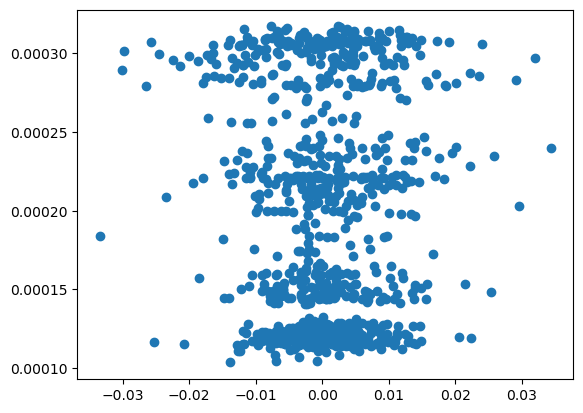

In [10]:
fig, ax= plt.subplots()
ax.scatter(train_df["forward_returns"][:1000], train_df["risk_free_rate"][:1000]);

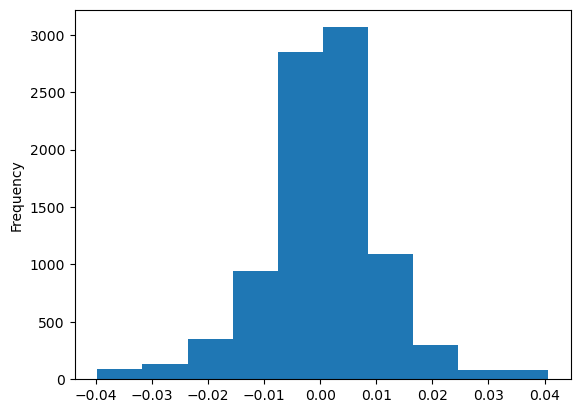

In [11]:
train_df.forward_returns.plot.hist();

In [12]:
train_df.std()

date_id                          2595.333794
D1                                  0.174917
D2                                  0.174917
D3                                  0.213420
D4                                  0.494341
                                    ...     
V8                                  0.351109
V9                                  1.277273
forward_returns                     0.010551
risk_free_rate                      0.000088
market_forward_excess_returns       0.010568
Length: 98, dtype: float64

In [13]:
missing_ratio = train_df.isna().mean().sort_values(ascending=False)
missing_ratio.head(60)

E7     0.775195
V10    0.672859
S3     0.637709
M1     0.617019
M13    0.616240
M14    0.616240
M6     0.560957
V9     0.504894
S12    0.393437
M5     0.365184
M2     0.357842
S8     0.334705
M3     0.224472
E1     0.198443
P6     0.182202
E20    0.179755
P7     0.179755
P5     0.175083
V5     0.168187
S5     0.168076
V7     0.168076
V13    0.168076
M8     0.111902
M9     0.111902
P1     0.111902
P4     0.111902
P10    0.111902
P11    0.111902
P12    0.111902
P13    0.111902
P2     0.111902
P3     0.111902
M7     0.111902
V6     0.111902
P8     0.111902
P9     0.111902
S1     0.111902
S10    0.111902
S11    0.111902
V8     0.111902
S2     0.111902
S4     0.111902
S6     0.111902
S7     0.111902
S9     0.111902
V1     0.111902
V11    0.111902
V12    0.111902
M4     0.111902
E10    0.111902
E11    0.111902
E19    0.111902
E8     0.111902
E6     0.111902
E5     0.111902
E4     0.111902
E3     0.111902
E2     0.111902
E18    0.111902
M18    0.111902
dtype: float64

In [14]:
missing_ratio.tail(38)

E17                              0.111902
E16                              0.111902
E15                              0.111902
E14                              0.111902
E13                              0.111902
E12                              0.111902
E9                               0.111902
I1                               0.111902
I2                               0.111902
I3                               0.111902
M17                              0.111902
M16                              0.111902
M15                              0.111902
V2                               0.111902
M12                              0.111902
M11                              0.111902
M10                              0.111902
V4                               0.111902
I9                               0.111902
I8                               0.111902
I7                               0.111902
I6                               0.111902
I5                               0.111902
I4                               0

## SQL-assisted Exploratory Data Analysis

**To complement Python-based EDA, SQL was used for structured querying, filtering, and aggregation of the market dataset before downstream preprocessing and modelling.**

In [15]:
import sqlite3

conn = sqlite3.connect(":memory:")
train_df.to_sql("market_data", conn, index=False, if_exists="replace")

8990

In [21]:
# filtering, quering the data
query = """
SELECT date_id, forward_returns, risk_free_rate
FROM market_data
WHERE forward_returns IS NOT NULL
ORDER BY date_id
LIMIT 10
"""
sql_preview = pd.read_sql(query, conn)
sql_preview

,date_id,forward_returns,risk_free_rate
0,0,-0.002421,0.000301
1,1,-0.008495,0.000303
2,2,-0.009624,0.000301
3,3,0.004662,0.000299
4,4,-0.011686,0.000299
5,5,-0.006449,0.000300
6,6,0.003644,0.000298
7,7,-0.024566,0.000300
8,8,-0.008492,0.000298
9,9,0.011263,0.000298


In [22]:
# aggregating the data
agg_query = """
SELECT
    AVG(forward_returns) AS avg_forward_return,
    MIN(forward_returns) AS min_forward_return,
    MAX(forward_returns) AS max_forward_return
FROM market_data
"""
sql_stats = pd.read_sql(agg_query, conn)
sql_stats

,avg_forward_return,min_forward_return,max_forward_return
0,0.000469,-0.039754,0.040661


**Results from SQL-based exploration will be used alongside pandas, NumPy, and visualization libraries
for deeper preprocessing, feature engineering, and time-series modeling.**

For dealing with missing values, we'll do interpolation and then we'll standardize the columns, so as to prepare the data for dimensionality reduction using PCA since 98 columns/features for a model development are "excessive".

In [15]:
def avg_nan_run_length(series):
    mask = series.isna()
    if not mask.any():
        return 0
    # Count consecutive runs of NaNs
    runs = (mask != mask.shift()).cumsum()
    return mask.groupby(runs).sum().mean()

for col in train_df.columns:
    avg_run = avg_nan_run_length(train_df[col])
    if avg_run > 5:
        print(f"{col}: LONG gaps (avg run = {avg_run:.1f})")
    elif avg_run > 0:
        print(f"{col}: short gaps (avg run = {avg_run:.1f})")

E1: LONG gaps (avg run = 892.0)
E10: LONG gaps (avg run = 503.0)
E11: LONG gaps (avg run = 503.0)
E12: LONG gaps (avg run = 503.0)
E13: LONG gaps (avg run = 503.0)
E14: LONG gaps (avg run = 503.0)
E15: LONG gaps (avg run = 503.0)
E16: LONG gaps (avg run = 503.0)
E17: LONG gaps (avg run = 503.0)
E18: LONG gaps (avg run = 503.0)
E19: LONG gaps (avg run = 503.0)
E2: LONG gaps (avg run = 503.0)
E20: LONG gaps (avg run = 808.0)
E3: LONG gaps (avg run = 503.0)
E4: LONG gaps (avg run = 503.0)
E5: LONG gaps (avg run = 503.0)
E6: LONG gaps (avg run = 503.0)
E7: LONG gaps (avg run = 3484.5)
E8: LONG gaps (avg run = 503.0)
E9: LONG gaps (avg run = 503.0)
I1: LONG gaps (avg run = 503.0)
I2: LONG gaps (avg run = 503.0)
I3: LONG gaps (avg run = 503.0)
I4: LONG gaps (avg run = 503.0)
I5: LONG gaps (avg run = 503.0)
I6: LONG gaps (avg run = 503.0)
I7: LONG gaps (avg run = 503.0)
I8: LONG gaps (avg run = 503.0)
I9: LONG gaps (avg run = 503.0)
M1: LONG gaps (avg run = 2773.5)
M10: LONG gaps (avg run = 5

In [16]:
long_gaps_col= [col for col in train_df.columns if avg_nan_run_length(train_df[col]) > 1000]
train_cleandf= train_df.drop(columns= long_gaps_col)

In [17]:
train_cleandf

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V2,V3,V4,V5,V6,V7,V8,forward_returns,risk_free_rate,market_forward_excess_returns
0,0,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002421,0.000301,-0.003038
1,1,0,0,0,1,1,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008495,0.000303,-0.009114
2,2,0,0,0,1,0,0,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009624,0.000301,-0.010243
3,3,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004662,0.000299,0.004046
4,4,0,0,0,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.011686,0.000299,-0.012301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8985,8985,0,0,0,0,0,0,0,0,0,...,0.785053,0.469577,0.837963,1.226772,0.822751,-0.707361,0.142857,0.002457,0.000155,0.001990
8986,8986,0,0,0,0,0,0,0,0,0,...,0.767857,0.671958,0.837963,0.785877,0.805556,-0.715692,0.196098,0.002312,0.000156,0.001845
8987,8987,0,0,1,0,0,0,0,0,0,...,0.734127,0.481481,0.787698,0.834898,0.823413,-0.723949,0.133929,0.002891,0.000156,0.002424
8988,8988,0,0,0,0,0,0,0,0,0,...,0.695106,0.655423,0.783730,0.994026,0.851852,-0.684937,0.101852,0.008310,0.000156,0.007843


In [18]:
feature_cols = [
    col for col in train_cleandf.columns
    if col not in [
        'forward_returns',
        'market_forward_excess_returns',
        'risk_free_rate'
    ]
]

In [19]:
a1= train_cleandf.isna().mean().sort_values(ascending=False)
a1.head(60)

E1     0.198443
P6     0.182202
P7     0.179755
E20    0.179755
P5     0.175083
V5     0.168187
S5     0.168076
V13    0.168076
V7     0.168076
M17    0.111902
P10    0.111902
P2     0.111902
P13    0.111902
P12    0.111902
P11    0.111902
M9     0.111902
P1     0.111902
M8     0.111902
P3     0.111902
V2     0.111902
M4     0.111902
M18    0.111902
M7     0.111902
M16    0.111902
P4     0.111902
M12    0.111902
P8     0.111902
P9     0.111902
S1     0.111902
S10    0.111902
S11    0.111902
S2     0.111902
S4     0.111902
S6     0.111902
S7     0.111902
S9     0.111902
V1     0.111902
V11    0.111902
M15    0.111902
I9     0.111902
M11    0.111902
E2     0.111902
V8     0.111902
V6     0.111902
V4     0.111902
V3     0.111902
E10    0.111902
E11    0.111902
E12    0.111902
E13    0.111902
E14    0.111902
E15    0.111902
E16    0.111902
E17    0.111902
E18    0.111902
M10    0.111902
E19    0.111902
E3     0.111902
E4     0.111902
I8     0.111902
dtype: float64

In [20]:
a1.tail(25)

I7                               0.111902
I6                               0.111902
I5                               0.111902
I4                               0.111902
I3                               0.111902
I2                               0.111902
I1                               0.111902
E9                               0.111902
E8                               0.111902
E6                               0.111902
E5                               0.111902
V12                              0.111902
forward_returns                  0.000000
risk_free_rate                   0.000000
date_id                          0.000000
D1                               0.000000
D9                               0.000000
D8                               0.000000
D7                               0.000000
D6                               0.000000
D5                               0.000000
D4                               0.000000
D3                               0.000000
D2                               0

## Visualizing Missing Columns/Features

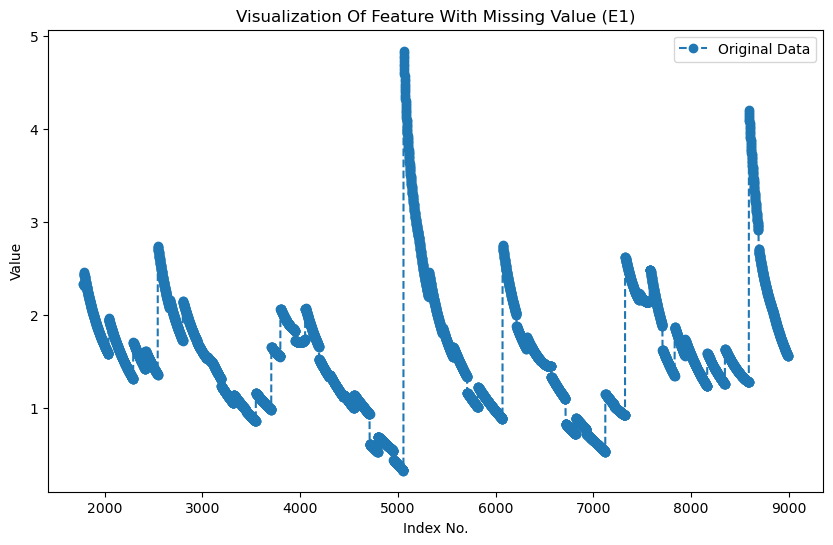

In [21]:
plt.figure(figsize=(10,6))
plt.plot(train_cleandf.index, train_cleandf["E1"], label="Original Data", marker="o", linestyle="--")
plt.legend()
plt.title("Visualization Of Feature With Missing Value (E1)")
plt.xlabel("Index No.")
plt.ylabel("Value")
plt.show()

In [22]:
train_cleandf["E1"].idxmax(), train_cleandf["E1"].max()

(5058, 4.84391083283968)

In [23]:
# Using Spline Interpolation
train_cleandf= train_cleandf.interpolate(method= "linear", limit_direction='both')

In [24]:
train_cleandf.isna().mean().head(60)

date_id    0.0
D1         0.0
D2         0.0
D3         0.0
D4         0.0
D5         0.0
D6         0.0
D7         0.0
D8         0.0
D9         0.0
E1         0.0
E10        0.0
E11        0.0
E12        0.0
E13        0.0
E14        0.0
E15        0.0
E16        0.0
E17        0.0
E18        0.0
E19        0.0
E2         0.0
E20        0.0
E3         0.0
E4         0.0
E5         0.0
E6         0.0
E8         0.0
E9         0.0
I1         0.0
I2         0.0
I3         0.0
I4         0.0
I5         0.0
I6         0.0
I7         0.0
I8         0.0
I9         0.0
M10        0.0
M11        0.0
M12        0.0
M15        0.0
M16        0.0
M17        0.0
M18        0.0
M4         0.0
M7         0.0
M8         0.0
M9         0.0
P1         0.0
P10        0.0
P11        0.0
P12        0.0
P13        0.0
P2         0.0
P3         0.0
P4         0.0
P5         0.0
P6         0.0
P7         0.0
dtype: float64

In [25]:
train_cleandf.isna().mean().tail(25)

P8                               0.0
P9                               0.0
S1                               0.0
S10                              0.0
S11                              0.0
S2                               0.0
S4                               0.0
S5                               0.0
S6                               0.0
S7                               0.0
S9                               0.0
V1                               0.0
V11                              0.0
V12                              0.0
V13                              0.0
V2                               0.0
V3                               0.0
V4                               0.0
V5                               0.0
V6                               0.0
V7                               0.0
V8                               0.0
forward_returns                  0.0
risk_free_rate                   0.0
market_forward_excess_returns    0.0
dtype: float64

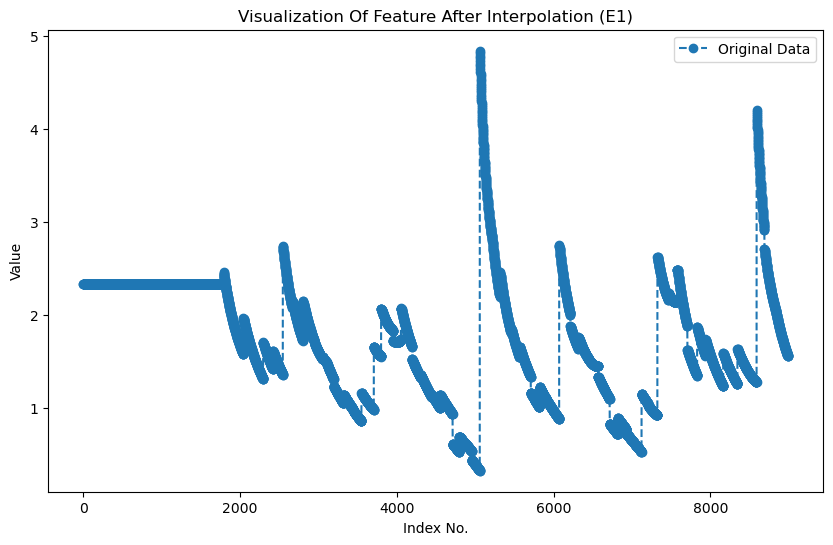

In [26]:
plt.figure(figsize=(10,6))
plt.plot(train_cleandf.index, train_cleandf["E1"], label="Original Data", marker="o", linestyle="--")
plt.legend()
plt.title("Visualization Of Feature After Interpolation (E1)")
plt.xlabel("Index No.")
plt.ylabel("Value")
plt.show()

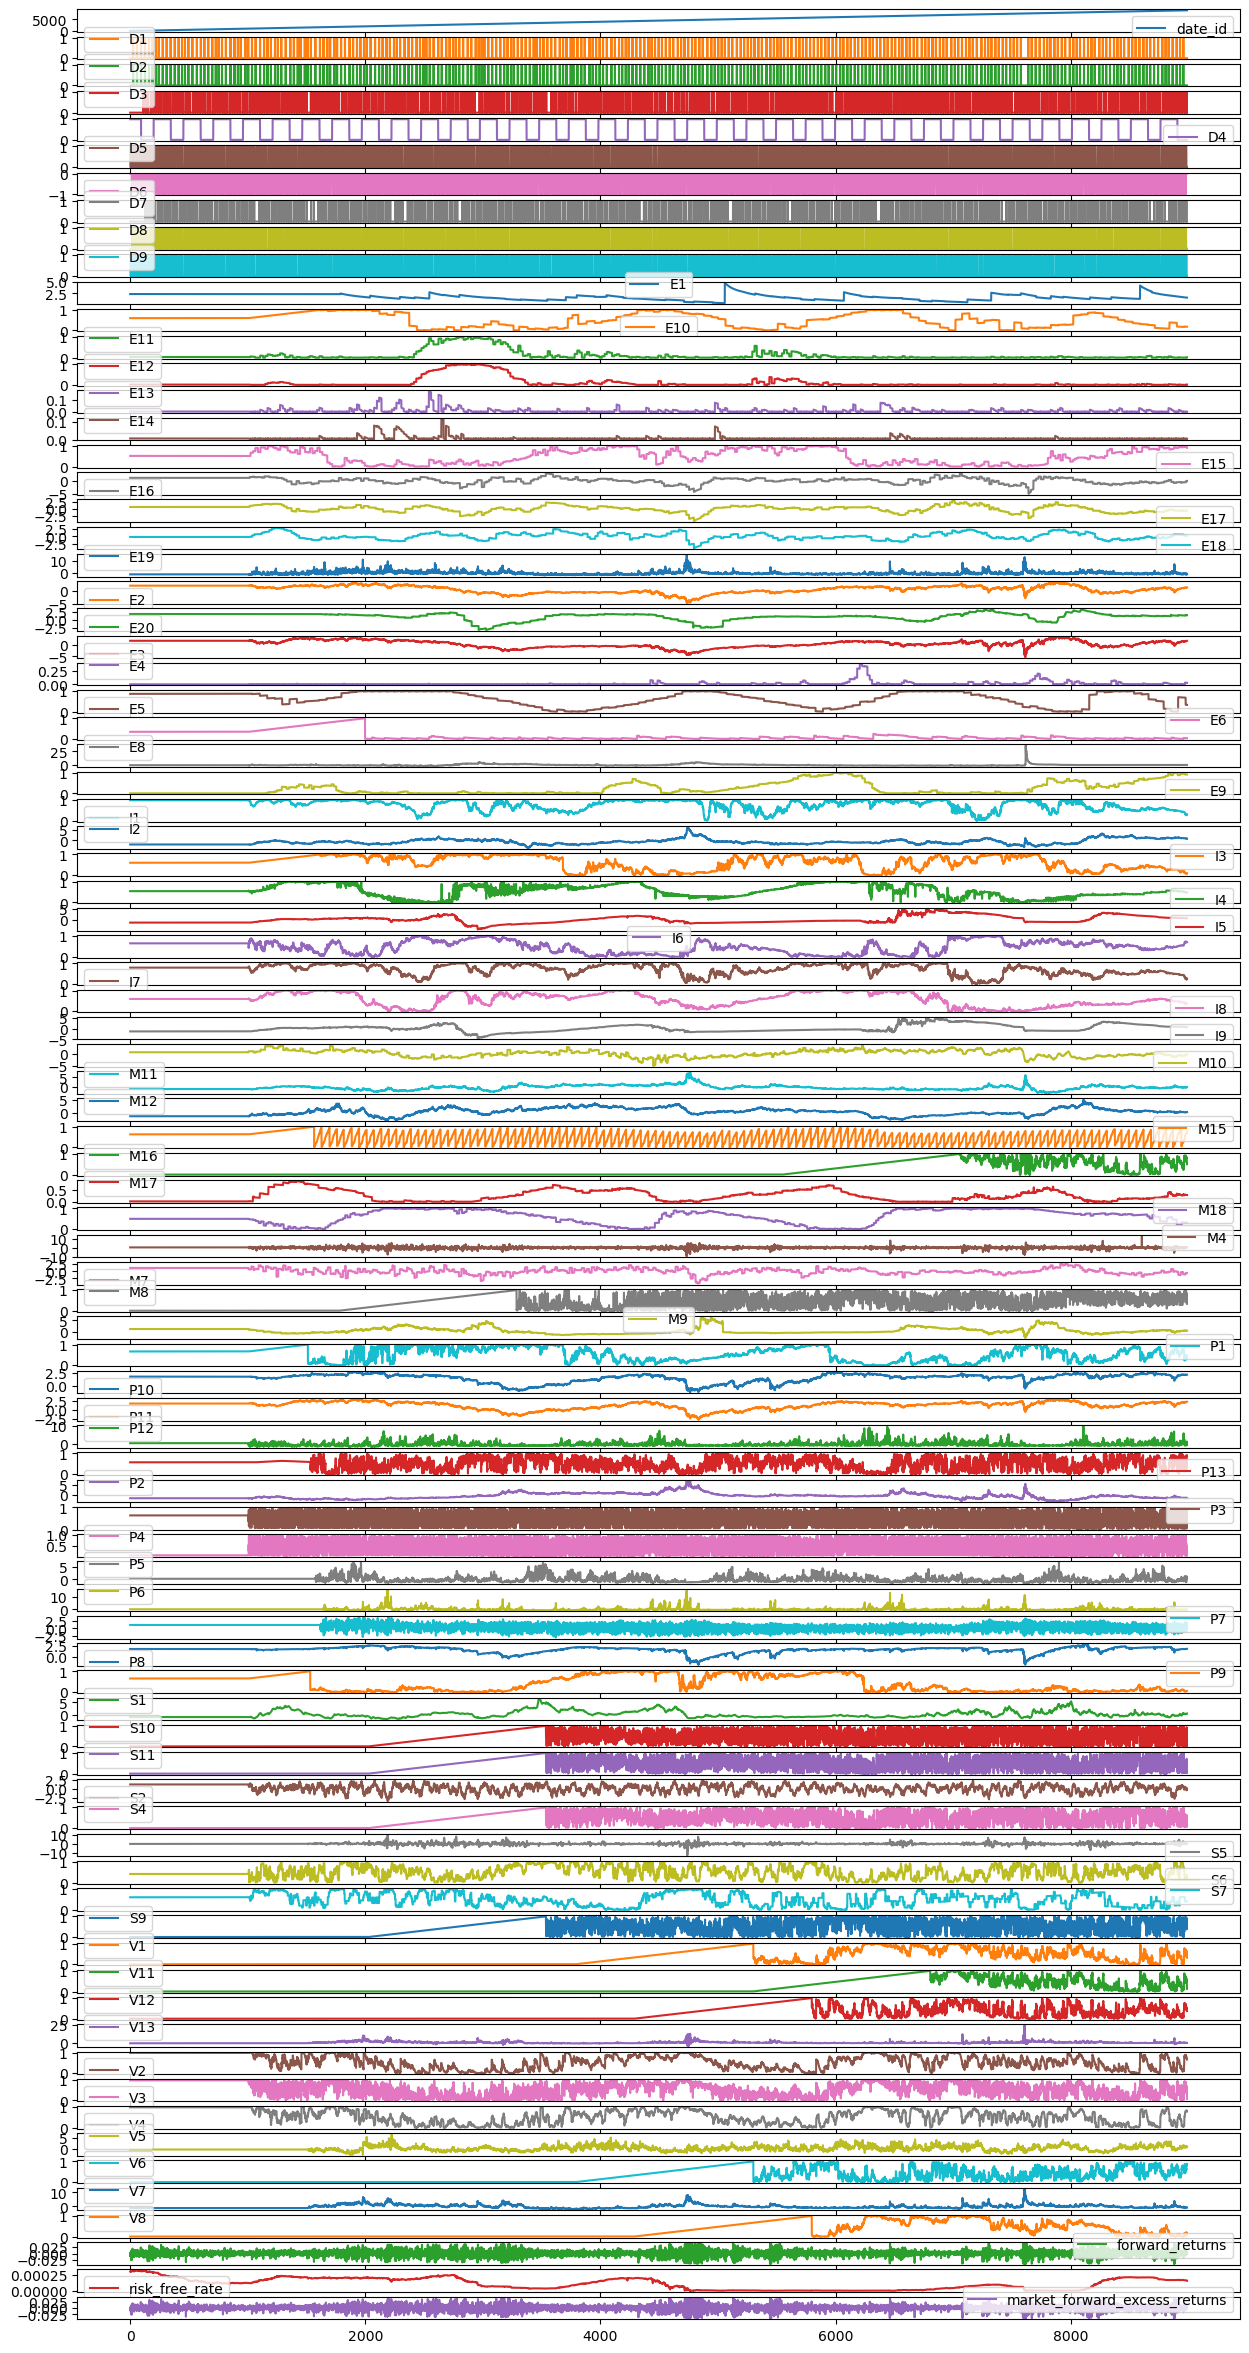

In [27]:
train_cleandf.plot(subplots=True, figsize=(15, 30));

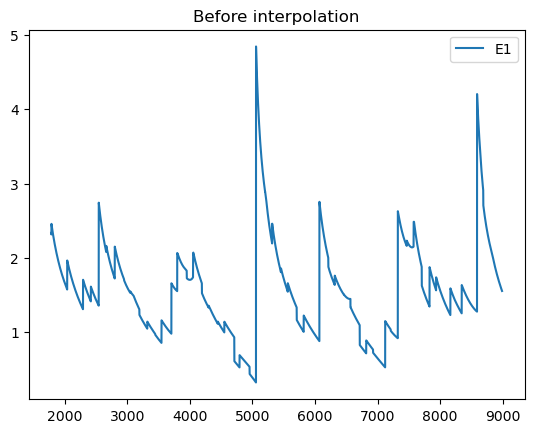

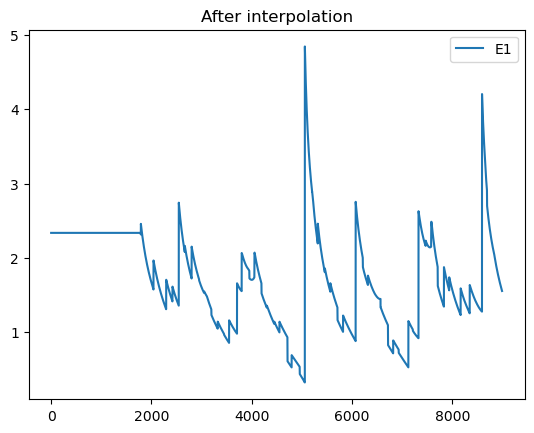

In [28]:
train_df[['E1']].plot(title='Before interpolation')
plt.savefig("Before Interpolation")
train_cleandf[['E1']].plot(title='After interpolation')
plt.savefig("After Interpolation")

In [29]:
train_cleandf["E1"]

0       2.337132
1       2.337132
2       2.337132
3       2.337132
4       2.337132
          ...   
8985    1.565379
8986    1.562946
8987    1.560520
8988    1.558102
8989    1.555690
Name: E1, Length: 8990, dtype: float64

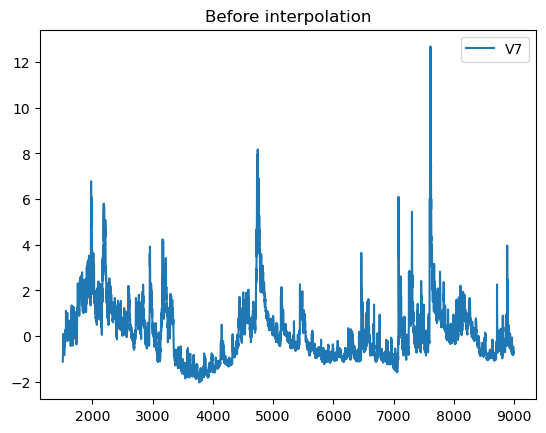

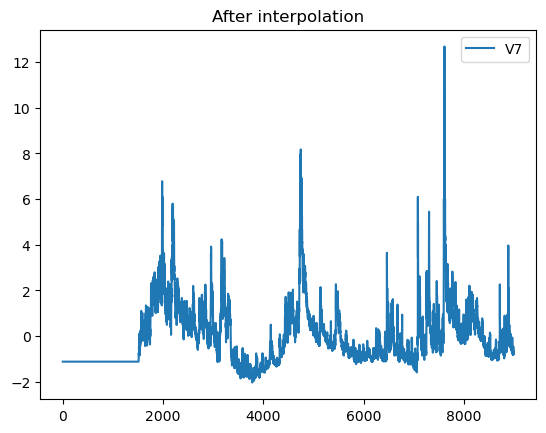

In [30]:
train_df[['V7']].plot(title='Before interpolation')
plt.savefig("Before Interpolation")
train_cleandf[['V7']].plot(title='After interpolation')
plt.savefig("After Interpolation")

In [31]:
train_cleandf["V7"]

0      -1.116040
1      -1.116040
2      -1.116040
3      -1.116040
4      -1.116040
          ...   
8985   -0.707361
8986   -0.715692
8987   -0.723949
8988   -0.684937
8989   -0.764806
Name: V7, Length: 8990, dtype: float64

## Standardization

In [32]:
y = train_cleandf['forward_returns']
X = train_cleandf[feature_cols]

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

In [34]:
X_scaled

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8
0,-1.731858,-0.180613,-0.180613,-0.224129,0.859385,2.060350,0.558935,-0.218878,-0.408195,2.446474,...,-0.664786,-0.748438,-0.733338,1.302843,1.311160,1.305446,-0.476670,-0.826736,-0.809563,-0.781988
1,-1.731473,-0.180613,-0.180613,-0.224129,0.859385,2.060350,0.558935,-0.218878,-0.408195,2.446474,...,-0.664786,-0.748438,-0.733338,1.302843,1.311160,1.305446,-0.476670,-0.826736,-0.809563,-0.781988
2,-1.731087,-0.180613,-0.180613,-0.224129,0.859385,-0.485355,0.558935,-0.218878,-0.408195,2.446474,...,-0.664786,-0.748438,-0.733338,1.302843,1.311160,1.305446,-0.476670,-0.826736,-0.809563,-0.781988
3,-1.730702,-0.180613,-0.180613,-0.224129,0.859385,-0.485355,0.558935,-0.218878,-0.408195,-0.408751,...,-0.664786,-0.748438,-0.733338,1.302843,1.311160,1.305446,-0.476670,-0.826736,-0.809563,-0.781988
4,-1.730317,-0.180613,-0.180613,-0.224129,0.859385,-0.485355,0.558935,-0.218878,-0.408195,-0.408751,...,-0.664786,-0.748438,-0.733338,1.302843,1.311160,1.305446,-0.476670,-0.826736,-0.809563,-0.781988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8985,1.730317,-0.180613,-0.180613,-0.224129,-1.163623,-0.485355,0.558935,-0.218878,-0.408195,-0.408751,...,1.166018,1.030107,-0.275531,0.683555,-0.226480,0.850987,0.889735,1.844270,-0.495008,-0.369102
8986,1.730702,-0.180613,-0.180613,-0.224129,-1.163623,-0.485355,0.558935,-0.218878,-0.408195,-0.408751,...,1.250168,1.005834,-0.273371,0.630763,0.394256,0.850987,0.480282,1.788400,-0.501421,-0.214509
8987,1.731087,-0.180613,-0.180613,4.461724,-1.163623,-0.485355,0.558935,-0.218878,-0.408195,-0.408751,...,0.621200,0.695802,-0.270226,0.527210,-0.189966,0.696796,0.525807,1.846418,-0.507776,-0.395027
8988,1.731473,-0.180613,-0.180613,-0.224129,-1.163623,-0.485355,0.558935,-0.218878,-0.408195,-0.408751,...,0.397879,0.564508,-0.238890,0.407413,0.343542,0.684623,0.673587,1.938818,-0.477750,-0.488167


In [35]:
X_scaled.std().round(2).head()   # should be around 1

date_id    1.0
D1         1.0
D2         1.0
D3         1.0
D4         1.0
dtype: float64

In [36]:
X_scaled.mean().round(2).head()  # should be around 0

date_id    0.0
D1        -0.0
D2        -0.0
D3        -0.0
D4        -0.0
dtype: float64

# PCA [Principal Component Analysis]

In [37]:
X

,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8
0,0,0,0,0,1,1,0,0,0,1,...,0.000661,0.000661,-1.020928,0.986772,0.970899,0.986111,-0.244560,0.000661,-1.116040,0.000661
1,1,0,0,0,1,1,0,0,0,1,...,0.000661,0.000661,-1.020928,0.986772,0.970899,0.986111,-0.244560,0.000661,-1.116040,0.000661
2,2,0,0,0,1,0,0,0,0,1,...,0.000661,0.000661,-1.020928,0.986772,0.970899,0.986111,-0.244560,0.000661,-1.116040,0.000661
3,3,0,0,0,1,0,0,0,0,0,...,0.000661,0.000661,-1.020928,0.986772,0.970899,0.986111,-0.244560,0.000661,-1.116040,0.000661
4,4,0,0,0,1,0,0,0,0,0,...,0.000661,0.000661,-1.020928,0.986772,0.970899,0.986111,-0.244560,0.000661,-1.116040,0.000661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8985,8985,0,0,0,0,0,0,0,0,0,...,0.561839,0.533730,-0.432282,0.785053,0.469577,0.837963,1.226772,0.822751,-0.707361,0.142857
8986,8986,0,0,0,0,0,0,0,0,0,...,0.587632,0.526455,-0.429506,0.767857,0.671958,0.837963,0.785877,0.805556,-0.715692,0.196098
8987,8987,0,0,1,0,0,0,0,0,0,...,0.394841,0.433532,-0.425462,0.734127,0.481481,0.787698,0.834898,0.823413,-0.723949,0.133929
8988,8988,0,0,0,0,0,0,0,0,0,...,0.326389,0.394180,-0.385170,0.695106,0.655423,0.783730,0.994026,0.851852,-0.684937,0.101852


In [38]:
y

0      -0.002421
1      -0.008495
2      -0.009624
3       0.004662
4      -0.011686
          ...   
8985    0.002457
8986    0.002312
8987    0.002891
8988    0.008310
8989    0.000099
Name: forward_returns, Length: 8990, dtype: float64

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [40]:
X_pca.shape

(8990, 44)

In [41]:
test_df = pd.read_csv("hull-tactical-unzip-dataset/test.csv")

In [42]:
test_cleandf = test_df.drop(columns=long_gaps_col)
test_cleandf = test_cleandf.interpolate(method='linear', limit_direction='both')

In [43]:
test_scaled = pd.DataFrame(
    scaler.transform(test_cleandf[feature_cols]),
    columns=feature_cols
)

In [44]:
X_test_pca = pca.transform(test_scaled)

# Training on train-val split

In [45]:
split = int(len(X_pca) * 0.8)

X_tr, X_val = X_pca[:split], X_pca[split:]
y_tr, y_val = y[:split], y[split:]

In [46]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [47]:
rf.fit(X_tr, y_tr)

RandomForestRegressor(max_depth=10, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [48]:
val_pred_rf = rf.predict(X_val)
val_pos_rf = np.clip(val_pred_rf * 50, 0, 2)

In [49]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_val, val_pred_rf)

0.0001336986353622889

In [50]:
test_pred_returns = rf.predict(X_test_pca)
positions = np.clip(test_pred_returns * 50, 0, 2)
submission = pd.DataFrame({"prediction": positions})

In [51]:
submission

,prediction
0,0.031150
1,0.029277
2,0.028335
3,0.022557
4,0.022658
5,0.026845
6,0.023201
7,0.014164
8,0.021344
9,0.022832


In [52]:
!pip install xgboost

In [53]:
import sys
!{sys.executable} -m pip install xgboost

In [54]:
import xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_tr, y_tr)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [55]:
val_pred_xgb = xgb.predict(X_val)

In [56]:
from sklearn.metrics import mean_squared_error
mse_xgb = mean_squared_error(y_val, val_pred_xgb)
mse_xgb

0.00013649731516777287

In [58]:
test_pred_returns = xgb.predict(X_test_pca)
positions = np.clip(test_pred_returns * 50, 0, 2)
submission = pd.DataFrame({"prediction": positions})

In [59]:
submission

,prediction
0,0.000000
1,0.000000
2,0.183351
3,0.084061
4,0.077904
5,0.000000
6,0.064847
7,0.000000
8,0.000000
9,0.000000


# Training on complete dataset

In [71]:
from sklearn.ensemble import RandomForestRegressor 

In [69]:
rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [70]:
rf_final.fit(X_pca, y)

RandomForestRegressor(max_depth=10, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [72]:
test_pred_returns = rf_final.predict(X_test_pca)

In [73]:
test_pred_returns

array([0.00048206, 0.0004486 , 0.0005773 , 0.00049354, 0.00054992,
       0.00045513, 0.00043628, 0.00040236, 0.00039659, 0.00046895])

In [81]:
# Convert to positions

import numpy as np

positions = np.clip(test_pred_returns * 200, 0, 2)

In [82]:
positions

array([0.09641164, 0.08972011, 0.11546014, 0.09870825, 0.10998498,
       0.09102563, 0.08725616, 0.08047265, 0.07931861, 0.09378928])

In [85]:
submission = pd.DataFrame({"prediction": positions})
submission

,prediction
0,0.096412
1,0.089720
2,0.115460
3,0.098708
4,0.109985
5,0.091026
6,0.087256
7,0.080473
8,0.079319
9,0.093789


In [88]:
# Convert to positions

import numpy as np
positions = np.clip(test_pred_returns * 100, 0, 2)

submission = pd.DataFrame({"prediction": positions})
submission

,prediction
0,0.048206
1,0.044860
2,0.057730
3,0.049354
4,0.054992
5,0.045513
6,0.043628
7,0.040236
8,0.039659
9,0.046895


In [99]:
# Convert to positions

import numpy as np

In [102]:
positions = np.clip(1 + test_pred_returns * 50, 0, 2)

submission = pd.DataFrame({
    "position prediction": positions
})

In [103]:
submission

,position prediction
0,1.024103
1,1.022430
2,1.028865
3,1.024677
4,1.027496
5,1.022756
6,1.021814
7,1.020118
8,1.019830
9,1.023447
